In [1]:
#!/usr/bin/env python3
"""
Updated hourly interpolation workflow for station variables + categorical MRoS
indicator kriging.

What this script does
---------------------
1. Interpolates continuous station variables using the existing methodology:
   - dynamic lapse-rate fit each hour + ordinary kriging of temperature residuals
   - Universal Kriging with DEM external drift for RH
2. Interpolates MRoS categories using one-hot indicator kriging.
3. Saves full-grid MRoS predictor surfaces as p_snow / p_mix / p_rain.
4. Builds a pointwise leave-one-out (LOOCV) MRoS prediction table from the raw
   MRoS observation dataset for leakage-safe ML predictors.

Notes
-----
- Raw MRoS observations remain the labels for later ML.
- The gridded MRoS probability surfaces are predictors only.
- The pointwise LOOCV output is the leakage-safe MRoS predictor product for ML.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple
import json
import warnings

import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.transform import rowcol as rio_rowcol
from rasterio.warp import calculate_default_transform, reproject, Resampling
import xarray as xr
from pyproj import CRS, Transformer
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
from tqdm import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)


In [ ]:

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
@dataclass
class IKConfig:
    base_dir: Path
    wy_start: str = "2024-10-01T00:00:00Z"
    wy_end: str = "2025-05-31T23:59:59Z"
    test_start: str = "2024-10-01T00:00:00Z"
    test_end: str = "2025-05-31T23:59:59Z"
    dem_path: Optional[Path] = None
    stations_parquet: Optional[Path] = None
    mros_parquet: Optional[Path] = None
    out_dir: Optional[Path] = None
    proj_fallback: str = "EPSG:26911"
    temp_vars: Tuple[str, ...] = ("temp_air", "temp_dew", "temp_wet")
    station_uk_vars: Tuple[str, ...] = ("rh",)
    mros_phase_probs: Tuple[str, ...] = ("p_snow", "p_mix", "p_rain")
    min_points_temp: int = 4
    min_points_rh: int = 4
    min_points_indicator: int = 4
    min_points_lapse: int = 5
    default_lapse_degC_per_m: float = -0.005
    lapse_bounds_degC_per_m: Tuple[float, float] = (-0.009, 0.002)
    variogram_model: str = "spherical"
    max_hours_for_variogram: int = 300
    max_points_per_hour_for_variogram: int = 30
    n_lags: int = 14
    pair_distance_quantile: float = 0.95
    variogram_min_pairs: int = 40
    variogram_min_bins: int = 5
    variogram_eps: float = 1e-6
    eps: float = 1e-6
    save_processed_parquet: bool = True
    reuse_processed: bool = True

    def __post_init__(self):
        if self.dem_path is None:
            self.dem_path = self.base_dir / "Data/elevation/DEM_1km_clipped.tif"
        if self.stations_parquet is None:
            self.stations_parquet = self.base_dir / "outputs/hourly_pipeline/hourly_data/stations_hourly.parquet"
        if self.mros_parquet is None:
            self.mros_parquet = self.base_dir / "outputs/hourly_pipeline/hourly_data/mros_hourly.parquet"
        if self.out_dir is None:
            self.out_dir = self.base_dir / "outputs/hourly_pipeline/indicator_kriging_refactored"
        self.out_dir.mkdir(parents=True, exist_ok=True)
        (self.out_dir / "processed_inputs").mkdir(parents=True, exist_ok=True)
        (self.out_dir / "variogram_calibration").mkdir(parents=True, exist_ok=True)

PHASE_COL_CANDIDATES = ("phase", "mros_phase", "phase_class", "ptype", "precip_phase", "phase_label")
PHASE_ALIASES = {
    "snow": "snow", "s": "snow", "sn": "snow", "solid": "snow",
    "mix": "mix", "mixed": "mix", "transition": "mix", "m": "mix",
    "rain": "rain", "r": "rain", "liquid": "rain",
    "rain_snow": "mix", "snow_rain": "mix", "rainsnow": "mix",
}
PHASE_ORDER = ("snow", "mix", "rain")
PHASE_TO_PROB = {"snow": "p_snow", "mix": "p_mix", "rain": "p_rain"}
MODEL_FUNCS = {}

# -----------------------------------------------------------------------------
# Utility / IO helpers
# -----------------------------------------------------------------------------
def default_base_dir() -> Path:
    return Path.cwd().parent   # if notebook is inside Scripts


def to_utc(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True).dt.floor("h")


def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso), freq="h", tz="UTC")


def ensure_columns(df: pd.DataFrame, required: Sequence[str], df_name: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")


def choose_projected_crs_from_dem(dem_path: Path, fallback: str = "EPSG:26911") -> CRS:
    with rio.open(dem_path) as src:
        crs = CRS.from_user_input(src.crs)
        if crs.is_projected:
            return crs
    return CRS.from_user_input(fallback)


def load_dem(path: Path, target_crs: CRS) -> Tuple[np.ndarray, dict, CRS]:
    with rio.open(path) as src:
        src_crs = CRS.from_user_input(src.crs)
        tgt_crs = CRS.from_user_input(target_crs)
        if src_crs == tgt_crs:
            dem = src.read(1).astype(np.float32)
            profile = src.profile.copy()
            profile["crs"] = tgt_crs.to_wkt()
            return dem, profile, tgt_crs
        transform, width, height = calculate_default_transform(src_crs, tgt_crs, src.width, src.height, *src.bounds)
        profile = src.profile.copy()
        profile.update({"crs": tgt_crs.to_wkt(), "transform": transform, "width": width, "height": height, "dtype": "float32"})
        dem = np.empty((height, width), dtype=np.float32)
        reproject(source=rio.band(src, 1), destination=dem, src_transform=src.transform, src_crs=src_crs,
                  dst_transform=transform, dst_crs=tgt_crs, resampling=Resampling.bilinear)
        return dem, profile, tgt_crs


def grid_centers(profile: dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return xs, ys, np.column_stack([X.ravel(), Y.ravel()])


def project_lonlat(df: pd.DataFrame, proj_crs: CRS) -> Tuple[np.ndarray, np.ndarray]:
    tfm = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    x, y = tfm.transform(df["lon"].values, df["lat"].values)
    return np.asarray(x), np.asarray(y)


def sample_dem_at_xy(xs: np.ndarray, ys: np.ndarray, dem_data: np.ndarray, dem_profile: dict) -> np.ndarray:
    rows, cols = rio_rowcol(dem_profile["transform"], xs, ys)
    rows = np.asarray(rows)
    cols = np.asarray(cols)
    valid = (rows >= 0) & (rows < dem_data.shape[0]) & (cols >= 0) & (cols < dem_data.shape[1])
    out = np.full(len(xs), np.nan, dtype=np.float32)
    out[valid] = dem_data[rows[valid], cols[valid]]
    nodata = dem_profile.get("nodata")
    if nodata is not None:
        out[np.isclose(out, nodata)] = np.nan
    return out


def attach_projected_xy_and_dem(df: pd.DataFrame, proj_crs: CRS, dem_data: np.ndarray, dem_profile: dict) -> pd.DataFrame:
    out = df.copy()
    x, y = project_lonlat(out, proj_crs)
    out["x"] = x
    out["y"] = y
    if "elev" not in out.columns:
        out["elev"] = np.nan
    need = out["elev"].isna()
    if need.any():
        out.loc[need, "elev"] = sample_dem_at_xy(out.loc[need, "x"].to_numpy(), out.loc[need, "y"].to_numpy(), dem_data, dem_profile)
    return out

# -----------------------------------------------------------------------------
# MRoS preprocessing
# -----------------------------------------------------------------------------
def infer_phase_column(df: pd.DataFrame) -> Optional[str]:
    for col in PHASE_COL_CANDIDATES:
        if col in df.columns:
            return col
    return None


def canonicalize_phase_value(v) -> Optional[str]:
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    return PHASE_ALIASES.get(s, s if s in PHASE_ORDER else None)


def convert_legacy_proxy_to_phase(v) -> Optional[str]:
    if pd.isna(v):
        return None
    try:
        fv = float(v)
    except Exception:
        return None
    if np.isclose(fv, 0.0):
        return "snow"
    if np.isclose(fv, 50.0):
        return "mix"
    if np.isclose(fv, 100.0):
        return "rain"
    return None


def prepare_mros_indicators(mros_df: pd.DataFrame) -> pd.DataFrame:
    df = mros_df.copy()
    phase_col = infer_phase_column(df)
    if phase_col is not None:
        df["mros_phase"] = df[phase_col].map(canonicalize_phase_value)
    elif "mros_plp_proxy" in df.columns:
        warnings.warn("No categorical MRoS phase column found; falling back to legacy mros_plp_proxy.")
        df["mros_phase"] = df["mros_plp_proxy"].map(convert_legacy_proxy_to_phase)
    else:
        raise ValueError("No categorical MRoS phase column found and no legacy mros_plp_proxy available.")
    for phase, out_col in PHASE_TO_PROB.items():
        df[out_col] = (df["mros_phase"] == phase).astype(float)
    return df


def dedupe_station_hourly(df: pd.DataFrame, value_cols: Sequence[str]) -> pd.DataFrame:
    grp = ["hour_utc", "lon", "lat"]
    def reducer(g: pd.DataFrame) -> pd.Series:
        out = {"hour_utc": g.name[0], "lon": g.name[1], "lat": g.name[2]}
        for c in value_cols:
            vals = pd.to_numeric(g[c], errors="coerce").dropna() if c in g.columns else pd.Series(dtype=float)
            out[c] = float(vals.mean()) if len(vals) else np.nan
        return pd.Series(out)
    return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)


def dedupe_mros_hourly(df: pd.DataFrame) -> pd.DataFrame:
    grp = ["hour_utc", "lon", "lat"]
    def reducer(g: pd.DataFrame) -> pd.Series:
        phases = g["mros_phase"].dropna().tolist()
        out = {"hour_utc": g.name[0], "lon": g.name[1], "lat": g.name[2]}
        if len(phases) == 0:
            out["mros_phase"] = None
            out["p_snow"] = np.nan
            out["p_mix"] = np.nan
            out["p_rain"] = np.nan
            return pd.Series(out)
        counts = pd.Series(phases).value_counts(normalize=True)
        out["mros_phase"] = counts.idxmax() if len(counts) == 1 else "soft_duplicate"
        out["p_snow"] = float(counts.get("snow", 0.0))
        out["p_mix"] = float(counts.get("mix", 0.0))
        out["p_rain"] = float(counts.get("rain", 0.0))
        return pd.Series(out)
    return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)

# -----------------------------------------------------------------------------
# Variogram helpers
# -----------------------------------------------------------------------------
def spherical_gamma(h, sill, rng, nugget):
    h = np.asarray(h, dtype=float)
    rng = max(float(rng), 1e-12)
    hr = h / rng
    return np.where(h <= rng, nugget + sill * (1.5 * hr - 0.5 * hr ** 3), nugget + sill)


def exponential_gamma(h, sill, rng, nugget):
    h = np.asarray(h, dtype=float)
    rng = max(float(rng), 1e-12)
    return nugget + sill * (1.0 - np.exp(-h / rng))


def gaussian_gamma(h, sill, rng, nugget):
    h = np.asarray(h, dtype=float)
    rng = max(float(rng), 1e-12)
    return nugget + sill * (1.0 - np.exp(-(h / rng) ** 2))

MODEL_FUNCS.update({"spherical": spherical_gamma, "exponential": exponential_gamma, "gaussian": gaussian_gamma})


def empirical_variogram_xy(x: np.ndarray, y: np.ndarray, z: np.ndarray, n_lags: int, q: float):
    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x = np.asarray(x)[keep]
    y = np.asarray(y)[keep]
    z = np.asarray(z)[keep]
    if len(z) < 3:
        return None
    coords = np.column_stack([x, y])
    dists = pdist(coords)
    if len(dists) == 0:
        return None
    semis = 0.5 * pdist(z.reshape(-1, 1), metric="sqeuclidean")
    dmax = np.quantile(dists, q)
    if not np.isfinite(dmax) or dmax <= 0:
        return None
    bins = np.linspace(0.0, dmax, n_lags + 1)
    lag_ids = np.digitize(dists, bins) - 1
    mids, gamma_emp, n_pairs = [], [], []
    for i in range(n_lags):
        mask = lag_ids == i
        if mask.sum() == 0:
            continue
        mids.append(0.5 * (bins[i] + bins[i + 1]))
        gamma_emp.append(np.nanmean(semis[mask]))
        n_pairs.append(int(mask.sum()))
    if len(mids) == 0:
        return None
    return {"dist_mid": np.asarray(mids), "gamma_emp": np.asarray(gamma_emp), "n_pairs": np.asarray(n_pairs)}


def fit_variogram_model(emp, model_name: str, var_name: str, eps: float):
    mids = np.asarray(emp["dist_mid"], dtype=float)
    gamma = np.asarray(emp["gamma_emp"], dtype=float)
    n_pairs = np.asarray(emp["n_pairs"], dtype=float)
    if len(mids) < 3:
        return None
    sill_guess = max(float(np.nanquantile(gamma, 0.9)), eps)
    range_guess = max(float(np.nanquantile(mids, 0.75)), eps)
    nugget_guess = max(float(np.nanmin(gamma)), 0.0)
    func = MODEL_FUNCS[model_name]
    try:
        popt, _ = curve_fit(
            func, mids, gamma,
            sigma=np.maximum(1.0 / np.sqrt(np.maximum(n_pairs, 1.0)), eps),
            p0=[sill_guess, range_guess, nugget_guess],
            bounds=([eps, eps, 0.0], [10.0 * max(sill_guess, 1.0), mids.max() * 3.0 + eps, max(sill_guess, 1.0)]),
            maxfev=5000,
        )
        sill, rng, nugget = map(float, popt)
    except Exception:
        sill, rng, nugget = sill_guess, range_guess, nugget_guess
    return {"variable": var_name, "model": model_name, "sill": max(sill, eps), "range": max(rng, eps), "nugget": max(nugget, 0.0), "psill": max(sill - nugget, eps)}


def pooled_hourly_variogram_fit(df: pd.DataFrame, value_col: str, cfg: IKConfig, fit_name: Optional[str] = None):
    fit_name = fit_name or value_col
    hours = pd.Series(df["hour_utc"].dropna().sort_values().unique())
    if len(hours) == 0:
        return None, None
    if len(hours) > cfg.max_hours_for_variogram:
        hours = hours.sample(cfg.max_hours_for_variogram, random_state=42).sort_values().reset_index(drop=True)
    mids_all, gamma_all, pairs_all = [], [], []
    for hour in hours:
        sub = df[df["hour_utc"] == hour].dropna(subset=["x", "y", value_col]).copy()
        if len(sub) > cfg.max_points_per_hour_for_variogram:
            sub = sub.sample(cfg.max_points_per_hour_for_variogram, random_state=42)
        if len(sub) < 3:
            continue
        emp = empirical_variogram_xy(sub["x"].to_numpy(), sub["y"].to_numpy(), sub[value_col].to_numpy(), cfg.n_lags, cfg.pair_distance_quantile)
        if emp is None:
            continue
        valid = emp["n_pairs"] >= cfg.variogram_min_pairs
        if valid.sum() < cfg.variogram_min_bins:
            continue
        mids_all.append(emp["dist_mid"][valid])
        gamma_all.append(emp["gamma_emp"][valid])
        pairs_all.append(emp["n_pairs"][valid])
    if not mids_all:
        return None, None
    mids = np.concatenate(mids_all)
    gamma = np.concatenate(gamma_all)
    n_pairs = np.concatenate(pairs_all)
    bins = np.linspace(mids.min(), mids.max() + cfg.variogram_eps, cfg.n_lags + 1)
    lag_ids = np.digitize(mids, bins) - 1
    mid_final, gamma_final, pair_final = [], [], []
    for i in range(cfg.n_lags):
        mask = lag_ids == i
        if not np.any(mask):
            continue
        w = n_pairs[mask]
        mid_final.append(float(np.average(mids[mask], weights=w)))
        gamma_final.append(float(np.average(gamma[mask], weights=w)))
        pair_final.append(int(np.sum(w)))
    pooled_emp = {"dist_mid": np.asarray(mid_final), "gamma_emp": np.asarray(gamma_final), "n_pairs": np.asarray(pair_final)}
    params = fit_variogram_model(pooled_emp, cfg.variogram_model, fit_name, cfg.variogram_eps)
    return params, pooled_emp

# -----------------------------------------------------------------------------
# Kriging wrappers
# -----------------------------------------------------------------------------
def pykrige_variogram_dict(params: Dict[str, float]) -> Dict[str, object]:
    return {"variogram_model": params["model"], "variogram_parameters": {"sill": params["sill"], "range": params["range"], "nugget": params["nugget"]}}


def ordinary_krige_grid(x, y, z, target_xy, params):
    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[keep], y[keep], z[keep]
    if len(z) < 3:
        return np.full(len(target_xy), np.nan, dtype=np.float32)
    try:
        ok = OrdinaryKriging(x, y, z, **pykrige_variogram_dict(params), enable_plotting=False, verbose=False)
        est, _ = ok.execute("points", target_xy[:, 0], target_xy[:, 1])
        return np.asarray(est, dtype=np.float32)
    except Exception:
        return np.full(len(target_xy), np.nan, dtype=np.float32)


def ordinary_krige_point(x, y, z, target_x, target_y, params) -> float:
    pred = ordinary_krige_grid(np.asarray(x), np.asarray(y), np.asarray(z), np.array([[target_x, target_y]], dtype=float), params)
    return float(pred[0]) if len(pred) else np.nan


def universal_krige_dem_grid(x, y, z, drift_train, target_xy, drift_target, params):
    keep = np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & np.isfinite(drift_train)
    x, y, z, drift_train = x[keep], y[keep], z[keep], drift_train[keep]
    if len(z) < 3:
        return np.full(len(target_xy), np.nan, dtype=np.float32)
    try:
        uk = UniversalKriging(x, y, z, drift_terms=["specified"], specified_drift=[drift_train], **pykrige_variogram_dict(params), enable_plotting=False, verbose=False)
        est, _ = uk.execute("points", target_xy[:, 0], target_xy[:, 1], specified_drift_arrays=[drift_target])
        return np.asarray(est, dtype=np.float32)
    except Exception:
        return np.full(len(target_xy), np.nan, dtype=np.float32)


def universal_krige_dem_point(x, y, z, drift_train, target_x, target_y, drift_target, params) -> float:
    pred = universal_krige_dem_grid(np.asarray(x), np.asarray(y), np.asarray(z), np.asarray(drift_train), np.array([[target_x, target_y]], dtype=float), np.array([drift_target], dtype=float), params)
    return float(pred[0]) if len(pred) else np.nan


def probability_closure(prob_cube: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    arr = np.asarray(prob_cube, dtype=float)
    arr = np.clip(arr, 0.0, 1.0)
    arr[~np.isfinite(arr)] = 0.0
    denom = np.sum(arr, axis=0)
    out = np.full_like(arr, np.nan, dtype=float)
    valid = denom > eps
    out[:, valid] = arr[:, valid] / denom[valid]
    return out

# -----------------------------------------------------------------------------
# Temperature model helpers
# -----------------------------------------------------------------------------
def estimate_lapse_rate_and_residuals(hour_points: pd.DataFrame, value_col: str, cfg: IKConfig):
    pts = hour_points.dropna(subset=["elev", value_col, "x", "y"]).copy()
    if len(pts) == 0:
        return pts, cfg.default_lapse_degC_per_m, 0.0
    slope = cfg.default_lapse_degC_per_m
    intercept = float(np.nanmean(pts[value_col])) if len(pts) else 0.0
    if len(pts) >= cfg.min_points_lapse:
        X = pts[["elev"]].to_numpy()
        y = pts[value_col].to_numpy()
        try:
            lr = LinearRegression()
            lr.fit(X, y)
            slope_candidate = float(lr.coef_[0])
            lo, hi = cfg.lapse_bounds_degC_per_m
            slope = float(np.clip(slope_candidate, lo, hi))
            intercept = float(lr.intercept_)
        except Exception:
            pass
    pts["resid"] = pts[value_col] - (intercept + slope * pts["elev"])
    return pts, slope, intercept

# -----------------------------------------------------------------------------
# Data preparation
# -----------------------------------------------------------------------------
def prepare_inputs(cfg: IKConfig, force_rebuild: bool = False):
    proc_dir = cfg.out_dir / "processed_inputs"
    st_proc = proc_dir / "stations_processed.parquet"
    mros_proc = proc_dir / "mros_processed.parquet"
    proj_crs = choose_projected_crs_from_dem(cfg.dem_path, cfg.proj_fallback)
    dem_data, dem_profile, proj_crs = load_dem(cfg.dem_path, proj_crs)

    if cfg.reuse_processed and not force_rebuild and st_proc.exists() and mros_proc.exists():
        return pd.read_parquet(st_proc), pd.read_parquet(mros_proc), dem_data, dem_profile, proj_crs

    st = pd.read_parquet(cfg.stations_parquet)
    mros = pd.read_parquet(cfg.mros_parquet)
    ensure_columns(st, ["hour_utc", "lon", "lat"], "stations parquet")
    ensure_columns(mros, ["hour_utc", "lon", "lat"], "MRoS parquet")
    st["hour_utc"] = to_utc(st["hour_utc"])
    mros["hour_utc"] = to_utc(mros["hour_utc"])
    time_mask_st = (st["hour_utc"] >= pd.to_datetime(cfg.test_start)) & (st["hour_utc"] <= pd.to_datetime(cfg.test_end))
    time_mask_m = (mros["hour_utc"] >= pd.to_datetime(cfg.test_start)) & (mros["hour_utc"] <= pd.to_datetime(cfg.test_end))
    st = st.loc[time_mask_st].copy()
    mros = mros.loc[time_mask_m].copy()
    available_station_vars = [c for c in list(cfg.temp_vars) + list(cfg.station_uk_vars) if c in st.columns]
    if not available_station_vars:
        raise ValueError("No configured station variables found in station parquet.")
    st = st[["hour_utc", "lon", "lat"] + available_station_vars].copy()
    st = dedupe_station_hourly(st, available_station_vars)
    st = attach_projected_xy_and_dem(st, proj_crs, dem_data, dem_profile)
    mros = prepare_mros_indicators(mros)
    mros = mros[["hour_utc", "lon", "lat", "mros_phase", "p_snow", "p_mix", "p_rain"]].copy()
    mros = dedupe_mros_hourly(mros)
    mros = attach_projected_xy_and_dem(mros, proj_crs, dem_data, dem_profile)
    st = st.dropna(subset=["x", "y"])
    mros = mros.dropna(subset=["x", "y"])
    if cfg.save_processed_parquet:
        st.to_parquet(st_proc, index=False)
        mros.to_parquet(mros_proc, index=False)
    return st, mros, dem_data, dem_profile, proj_crs

# -----------------------------------------------------------------------------
# Variogram calibration
# -----------------------------------------------------------------------------
def calibrate_variograms(st_hr: pd.DataFrame, mros_hr: pd.DataFrame, cfg: IKConfig):
    params, summary_rows, bins_dict = {}, [], {}
    for var in [c for c in cfg.temp_vars if c in st_hr.columns]:
        rows = []
        for t in pd.Series(st_hr["hour_utc"].dropna().unique()):
            sub = st_hr[st_hr["hour_utc"] == t].copy()
            pts, _, _ = estimate_lapse_rate_and_residuals(sub, var, cfg)
            if len(pts):
                rows.append(pts[["hour_utc", "x", "y", "resid"]].rename(columns={"resid": f"{var}_resid"}))
        if rows:
            fit_df = pd.concat(rows, ignore_index=True)
            fit, emp = pooled_hourly_variogram_fit(fit_df, f"{var}_resid", cfg, fit_name=f"{var}_resid")
            if fit is not None:
                params[f"{var}_resid"] = fit
                bins_dict[f"{var}_resid"] = emp
                summary_rows.append(fit)
    for var in [c for c in cfg.station_uk_vars if c in st_hr.columns]:
        fit, emp = pooled_hourly_variogram_fit(st_hr, var, cfg, fit_name=var)
        if fit is not None:
            params[var] = fit
            bins_dict[var] = emp
            summary_rows.append(fit)
    for prob_col in cfg.mros_phase_probs:
        fit, emp = pooled_hourly_variogram_fit(mros_hr, prob_col, cfg, fit_name=prob_col)
        if fit is not None:
            params[prob_col] = fit
            bins_dict[prob_col] = emp
            summary_rows.append(fit)
    summary = pd.DataFrame(summary_rows)
    with open(cfg.out_dir / "variogram_calibration" / "variogram_params.json", "w", encoding="utf-8") as f:
        json.dump(params, f, indent=2)
    summary.to_csv(cfg.out_dir / "variogram_calibration" / "variogram_summary.csv", index=False)
    return params, summary, bins_dict

# -----------------------------------------------------------------------------
# Hourly interpolation
# -----------------------------------------------------------------------------
def interpolate_temperature_hour(st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg):
    if f"{var}_resid" not in variogram_params:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    pts, slope, intercept = estimate_lapse_rate_and_residuals(st_t, var, cfg)
    pts = pts.dropna(subset=["x", "y", "resid"])
    if len(pts) < cfg.min_points_temp:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    resid_pred = ordinary_krige_grid(pts["x"].to_numpy(), pts["y"].to_numpy(), pts["resid"].to_numpy(), grid_xy_valid, variogram_params[f"{var}_resid"])
    return (intercept + slope * dem_valid + resid_pred).astype(np.float32)


def interpolate_rh_hour(st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg):
    if var not in variogram_params:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    sub = st_t.dropna(subset=["x", "y", "elev", var]).copy()
    if len(sub) < cfg.min_points_rh:
        return np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
    return universal_krige_dem_grid(sub["x"].to_numpy(), sub["y"].to_numpy(), sub[var].to_numpy(), sub["elev"].to_numpy(), grid_xy_valid, dem_valid, variogram_params[var])


def interpolate_mros_indicator_hour(mros_t, grid_xy_valid, variogram_params, cfg):
    sub = mros_t.dropna(subset=["x", "y"]).copy()
    pred = {}
    if len(sub) < cfg.min_points_indicator:
        for col in cfg.mros_phase_probs:
            pred[col] = np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
        return pred
    for col in cfg.mros_phase_probs:
        col_sub = sub.dropna(subset=[col]).copy()
        if len(col_sub) < cfg.min_points_indicator or col not in variogram_params:
            pred[col] = np.full(len(grid_xy_valid), np.nan, dtype=np.float32)
            continue
        pred[col] = ordinary_krige_grid(col_sub["x"].to_numpy(), col_sub["y"].to_numpy(), col_sub[col].to_numpy(), grid_xy_valid, variogram_params[col])
    cube = np.vstack([pred["p_snow"], pred["p_mix"], pred["p_rain"]])
    cube = probability_closure(cube, eps=cfg.eps)
    pred["p_snow"], pred["p_mix"], pred["p_rain"] = [cube[i].astype(np.float32) for i in range(3)]
    return pred

# -----------------------------------------------------------------------------
# Pointwise LOOCV for leakage-safe MRoS predictors
# -----------------------------------------------------------------------------
def interpolate_mros_indicator_point_loocv(train_df: pd.DataFrame, target_row: pd.Series, variogram_params: Dict[str, Dict[str, float]], cfg: IKConfig):
    sub = train_df.dropna(subset=["x", "y"]).copy()
    if len(sub) < cfg.min_points_indicator:
        return {col: np.nan for col in cfg.mros_phase_probs}
    pred = {}
    for col in cfg.mros_phase_probs:
        col_sub = sub.dropna(subset=[col]).copy()
        if len(col_sub) < cfg.min_points_indicator or col not in variogram_params:
            pred[col] = np.nan
            continue
        pred[col] = ordinary_krige_point(col_sub["x"].to_numpy(), col_sub["y"].to_numpy(), col_sub[col].to_numpy(), float(target_row["x"]), float(target_row["y"]), variogram_params[col])
    cube = probability_closure(np.array([[pred["p_snow"]], [pred["p_mix"]], [pred["p_rain"]]], dtype=float), eps=cfg.eps)
    return {"p_snow": float(cube[0, 0]), "p_mix": float(cube[1, 0]), "p_rain": float(cube[2, 0])}


def loocv_mros_hour(mros_t: pd.DataFrame, variogram_params: Dict[str, Dict[str, float]], cfg: IKConfig):
    cols_needed = ["x", "y", "elev", "mros_phase", "p_snow", "p_mix", "p_rain"]
    df = mros_t.dropna(subset=cols_needed).copy()
    if len(df) < max(cfg.min_points_indicator + 1, 3):
        return pd.DataFrame(), {"n_points": len(df), "n_eval": 0, "accuracy": np.nan, "macro_f1": np.nan, "multiclass_logloss": np.nan}
    rows = []
    for i in range(len(df)):
        test = df.iloc[i]
        train = df.drop(df.index[i])
        pred = interpolate_mros_indicator_point_loocv(train, test, variogram_params, cfg)
        if any(pd.isna(list(pred.values()))):
            continue
        probs = [pred["p_snow"], pred["p_mix"], pred["p_rain"]]
        pred_phase = PHASE_ORDER[int(np.argmax(probs))]
        rows.append({
            "lon": float(test["lon"]), "lat": float(test["lat"]), "x": float(test["x"]), "y": float(test["y"]), "elev": float(test["elev"]),
            "obs_phase": test["mros_phase"], "pred_phase": pred_phase,
            "mros_p_snow_loocv": pred["p_snow"], "mros_p_mix_loocv": pred["p_mix"], "mros_p_rain_loocv": pred["p_rain"],
            "obs_p_snow": float(test["p_snow"]), "obs_p_mix": float(test["p_mix"]), "obs_p_rain": float(test["p_rain"]),
            "pred_max_prob": float(np.max(probs)),
            "pred_entropy": float(-np.sum(np.clip(probs, cfg.eps, 1.0) * np.log(np.clip(probs, cfg.eps, 1.0)))),
            "pred_correct": int(pred_phase == test["mros_phase"]),
        })
    details = pd.DataFrame(rows)
    if details.empty:
        return details, {"n_points": len(df), "n_eval": 0, "accuracy": np.nan, "macro_f1": np.nan, "multiclass_logloss": np.nan}
    y_true = details["obs_phase"].values
    y_pred = details["pred_phase"].values
    y_prob = details[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values
    y_onehot = details[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values
    metrics = {"n_points": len(df), "n_eval": len(details), "accuracy": accuracy_score(y_true, y_pred), "macro_f1": f1_score(y_true, y_pred, labels=PHASE_ORDER, average="macro")}
    try:
        metrics["multiclass_logloss"] = log_loss(y_onehot, y_prob)
    except Exception:
        metrics["multiclass_logloss"] = np.nan
    return details, metrics


def summarize_loocv(points_df: pd.DataFrame) -> pd.DataFrame:
    if points_df.empty:
        return pd.DataFrame([{"scope": "overall", "n_eval": 0, "accuracy": np.nan, "macro_f1": np.nan, "multiclass_logloss": np.nan}])
    overall = {"scope": "overall", "n_eval": len(points_df), "accuracy": accuracy_score(points_df["obs_phase"], points_df["pred_phase"]), "macro_f1": f1_score(points_df["obs_phase"], points_df["pred_phase"], labels=PHASE_ORDER, average="macro")}
    try:
        overall["multiclass_logloss"] = log_loss(points_df[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values, points_df[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values)
    except Exception:
        overall["multiclass_logloss"] = np.nan
    by_hour = []
    for hour, g in points_df.groupby("hour_utc"):
        row = {"scope": "hourly", "hour_utc": hour, "n_eval": len(g)}
        row["accuracy"] = accuracy_score(g["obs_phase"], g["pred_phase"]) if len(g) else np.nan
        row["macro_f1"] = f1_score(g["obs_phase"], g["pred_phase"], labels=PHASE_ORDER, average="macro") if len(g) else np.nan
        try:
            row["multiclass_logloss"] = log_loss(g[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values, g[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values)
        except Exception:
            row["multiclass_logloss"] = np.nan
        by_hour.append(row)
    return pd.concat([pd.DataFrame([overall]), pd.DataFrame(by_hour)], ignore_index=True)

# -----------------------------------------------------------------------------
# Main run
# -----------------------------------------------------------------------------
def interpolate_all_hours(st_hr, mros_hr, dem_data, dem_profile, proj_crs, variogram_params, cfg):
    x_centers, y_centers, grid_xy = grid_centers(dem_profile)
    H, W = dem_data.shape
    valid_points = np.isfinite(dem_data).ravel()
    grid_xy_valid = grid_xy[valid_points]
    dem_valid = dem_data.ravel()[valid_points].astype(np.float32)
    times = hourly_index(cfg.test_start, cfg.test_end)
    out_vars = [c for c in cfg.temp_vars if c in st_hr.columns] + [c for c in cfg.station_uk_vars if c in st_hr.columns] + list(cfg.mros_phase_probs)
    data_vars = {v: np.full((len(times), H, W), np.nan, dtype=np.float32) for v in out_vars}
    loocv_point_rows = []

    for ti, t in enumerate(tqdm(times, desc="Interpolating hours")):
        st_t = st_hr[st_hr["hour_utc"] == t].copy()
        mros_t = mros_hr[mros_hr["hour_utc"] == t].copy()

        for var in [c for c in cfg.temp_vars if c in st_hr.columns]:
            vals = interpolate_temperature_hour(st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg)
            full = np.full(H * W, np.nan, dtype=np.float32)
            full[valid_points] = vals
            data_vars[var][ti, :, :] = full.reshape(H, W)

        for var in [c for c in cfg.station_uk_vars if c in st_hr.columns]:
            vals = interpolate_rh_hour(st_t, var, grid_xy_valid, dem_valid, variogram_params, cfg)
            full = np.full(H * W, np.nan, dtype=np.float32)
            full[valid_points] = vals
            data_vars[var][ti, :, :] = full.reshape(H, W)

        pred = interpolate_mros_indicator_hour(mros_t, grid_xy_valid, variogram_params, cfg)
        for col in cfg.mros_phase_probs:
            full = np.full(H * W, np.nan, dtype=np.float32)
            full[valid_points] = pred[col]
            data_vars[col][ti, :, :] = full.reshape(H, W)

        details, _ = loocv_mros_hour(mros_t, variogram_params, cfg)
        if len(details):
            details = details.copy()
            details["hour_utc"] = t
            loocv_point_rows.append(details)

    ds = xr.Dataset(
        data_vars={k: (("time", "y", "x"), arr) for k, arr in data_vars.items()},
        coords={"time": pd.to_datetime(times).tz_convert(None), "y": y_centers, "x": x_centers},
        attrs={
            "crs": str(proj_crs),
            "description": "Hourly station interpolation + categorical MRoS indicator kriging",
            "mros_note": "p_snow/p_mix/p_rain are predictor surfaces only; raw MRoS points remain labels.",
        },
    )
    loocv_points = pd.concat(loocv_point_rows, ignore_index=True) if loocv_point_rows else pd.DataFrame()
    loocv_summary = summarize_loocv(loocv_points)
    ds.to_netcdf(cfg.out_dir / "hourly_predictors_1km_indicator_kriging.nc")
    if not loocv_points.empty:
        loocv_points.to_parquet(cfg.out_dir / "mros_loocv_point_predictions_kriging.parquet", index=False)
        loocv_points.to_csv(cfg.out_dir / "mros_loocv_point_predictions_kriging.csv", index=False)
    loocv_summary.to_csv(cfg.out_dir / "mros_loocv_summary_kriging.csv", index=False)
    return ds, loocv_summary, loocv_points


def build_default_config(base_dir: Optional[Path] = None) -> IKConfig:
    cfg = IKConfig(base_dir=base_dir or default_base_dir())
    for p in [cfg.dem_path, cfg.stations_parquet, cfg.mros_parquet]:
        if not Path(p).exists():
            raise FileNotFoundError(f"Missing required input: {p}/nCurrent base_dir is {cfg.base_dir}. Set IKConfig(base_dir=...) to your project root.")
    return cfg


def main(cfg: Optional[IKConfig] = None, force_rebuild_processed: bool = False):
    cfg = cfg or build_default_config()
    st_hr, mros_hr, dem_data, dem_profile, proj_crs = prepare_inputs(cfg, force_rebuild=force_rebuild_processed)
    variogram_params, variogram_summary, variogram_bins = calibrate_variograms(st_hr, mros_hr, cfg)
    ds, cv_summary, cv_details = interpolate_all_hours(st_hr, mros_hr, dem_data, dem_profile, proj_crs, variogram_params, cfg)
    return {
        "config": cfg,
        "st_hr_processed": st_hr,
        "mros_hr_processed": mros_hr,
        "variogram_params": variogram_params,
        "variogram_summary": variogram_summary,
        "variogram_bins": variogram_bins,
        "ds_interp": ds,
        "mros_loocv_summary": cv_summary,
        "mros_loocv_points": cv_details,
    }


if __name__ == "__main__":
    results = main()
    print("Run complete.")
    for k in results.keys():
        if k != "config":
            print(" -", k)


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_66928\3551307211.py:203: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_66928\3551307211.py:223: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)
Interpol

Run complete.
 - st_hr_processed
 - mros_hr_processed
 - variogram_params
 - variogram_summary
 - variogram_bins
 - ds_interp
 - mros_loocv_summary
 - mros_loocv_points


DATASET SUMMARY
<xarray.Dataset> Size: 6GB
Dimensions:   (time: 5832, y: 251, x: 142)
Coordinates:
  * time      (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:00:00
  * y         (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x         (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
Data variables:
    temp_air  (time, y, x) float32 831MB ...
    temp_dew  (time, y, x) float32 831MB ...
    temp_wet  (time, y, x) float32 831MB ...
    rh        (time, y, x) float32 831MB ...
    p_snow    (time, y, x) float32 831MB ...
    p_mix     (time, y, x) float32 831MB ...
    p_rain    (time, y, x) float32 831MB ...
Attributes:
    crs:          PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_A...
    description:  Hourly station interpolation + categorical MRoS indicator k...
    mros_note:    p_snow/p_mix/p_rain are predictor surfaces only; raw MRoS p...

Variables in dataset:
['temp_air', 'temp_dew', 'temp_wet', 'rh', 'p_snow', 'p_mix', 'p_rai

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_53588\3545907097.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_53588\3545907097.py:219: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_53588\3545907097.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_53588\3545907097.py:219: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

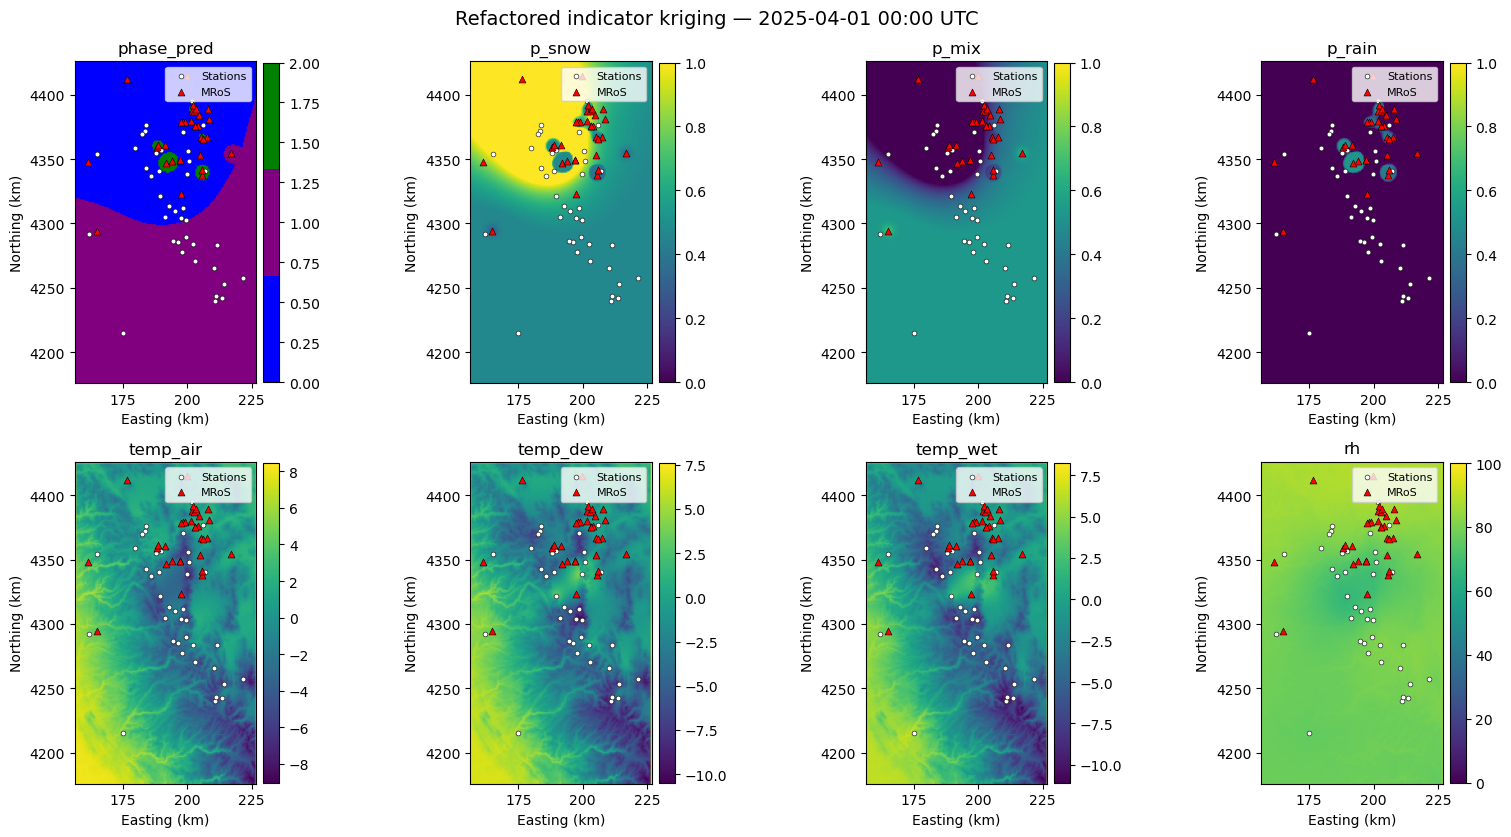


QUICK QC
temp_air   | finite=100.00% | min=  -9.028 | max=   8.459 | mean=   0.752
temp_dew   | finite=100.00% | min= -10.476 | max=   7.601 | mean=  -0.806
temp_wet   | finite=100.00% | min= -11.076 | max=   8.237 | mean=  -1.112
rh         | finite=100.00% | min=  65.747 | max=  91.417 | mean=  79.406
p_snow     | finite=100.00% | min=   0.275 | max=   1.000 | mean=   0.614
p_mix      | finite=100.00% | min=   0.000 | max=   0.725 | mean=   0.377
p_rain     | finite=100.00% | min=   0.000 | max=   0.530 | mean=   0.009

Probability sum check at plotted timestep:
min  = 1.0000
max  = 1.0000
mean = 1.0000
std  = 0.0000

Quicklook complete.


In [3]:
# =============================================================================
# QUICKLOOK – REFACTORED KRIGING SUPPORT SURFACES (SINGLE DATE)
# =============================================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer, CRS
from matplotlib.colors import ListedColormap


# ------------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------------

KRIG_PATH = Path(
    r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype"
    r"\outputs\hourly_pipeline\indicator_kriging_refactored"
    r"\hourly_predictors_1km_indicator_kriging.nc"
)

STATION_PATH = Path(
    r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype"
    r"\outputs\hourly_pipeline\hourly_data\stations_hourly.parquet"
)

MROS_PATH = Path(
    r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype"
    r"\outputs\hourly_pipeline\hourly_data\mros_hourly.parquet"
)

TARGET_DATE = "2025-04-01"


# ------------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------------

ds = xr.open_dataset(KRIG_PATH)
st_hr = pd.read_parquet(STATION_PATH)
mros_hr = pd.read_parquet(MROS_PATH)

print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(ds)

print("\nVariables in dataset:")
print(list(ds.data_vars))


# ------------------------------------------------------------------
# FIND TIMESTAMP
# ------------------------------------------------------------------

times = pd.to_datetime(ds.time.values).floor("h")
mask = times.normalize() == pd.to_datetime(TARGET_DATE)

if not mask.any():
    raise ValueError(f"No timestep found for {TARGET_DATE}")

ti = np.where(mask)[0][0]
t_plot = times[ti]

print("\nPlotting timestep:", t_plot)


# ------------------------------------------------------------------
# GRID EXTENT
# ------------------------------------------------------------------

xmin, xmax = ds.x.min().item(), ds.x.max().item()
ymin, ymax = ds.y.min().item(), ds.y.max().item()
extent = [xmin, xmax, ymin, ymax]


# ------------------------------------------------------------------
# RESOLVE CRS
# ------------------------------------------------------------------

if "spatial_ref" in ds and "crs_wkt" in ds["spatial_ref"].attrs:
    ds_crs = ds["spatial_ref"].attrs["crs_wkt"]
elif "crs" in ds.attrs:
    ds_crs = ds.attrs["crs"]
else:
    raise ValueError("No CRS information found in dataset (neither spatial_ref nor global crs attr).")

tf = Transformer.from_crs("EPSG:4326", CRS.from_user_input(ds_crs), always_xy=True)


# ------------------------------------------------------------------
# FILTER OBS TO MATCHING HOUR
# ------------------------------------------------------------------

if st_hr["hour_utc"].dt.tz is not None:
    st_time = st_hr["hour_utc"].dt.tz_convert(None)
else:
    st_time = st_hr["hour_utc"]

if mros_hr["hour_utc"].dt.tz is not None:
    mros_time = mros_hr["hour_utc"].dt.tz_convert(None)
else:
    mros_time = mros_hr["hour_utc"]

st_t = st_hr[st_time.dt.floor("h") == t_plot].copy()
mros_t = mros_hr[mros_time.dt.floor("h") == t_plot].copy()


# ------------------------------------------------------------------
# PROJECT OBSERVATIONS
# ------------------------------------------------------------------

st_x, st_y = np.array([]), np.array([])
if len(st_t):
    sx, sy = tf.transform(st_t["lon"].values, st_t["lat"].values)
    sx, sy = np.asarray(sx), np.asarray(sy)
    st_mask = (sx >= xmin) & (sx <= xmax) & (sy >= ymin) & (sy <= ymax)
    st_x, st_y = sx[st_mask], sy[st_mask]

mo_x, mo_y = np.array([]), np.array([])
if len(mros_t):
    mx, my = tf.transform(mros_t["lon"].values, mros_t["lat"].values)
    mx, my = np.asarray(mx), np.asarray(my)
    mo_mask = (mx >= xmin) & (mx <= xmax) & (my >= ymin) & (my <= ymax)
    mo_x, mo_y = mx[mo_mask], my[mo_mask]

print(f"Stations in grid: {len(st_x)}")
print(f"MRoS in grid:     {len(mo_x)}")


# ------------------------------------------------------------------
# BUILD PHASE MAP FROM p_snow / p_mix / p_rain
# ------------------------------------------------------------------

p_snow = ds["p_snow"].isel(time=ti).values
p_mix  = ds["p_mix"].isel(time=ti).values
p_rain = ds["p_rain"].isel(time=ti).values

phase_pred = np.argmax(np.stack([p_snow, p_mix, p_rain]), axis=0)

phase_cmap = ListedColormap(["blue", "purple", "green"])  # snow, mix, rain


# ------------------------------------------------------------------
# VARIABLES TO PLOT
# ------------------------------------------------------------------

vars_to_plot = [
    ("phase_pred", phase_pred),
    ("p_snow", p_snow),
    ("p_mix", p_mix),
    ("p_rain", p_rain),
    ("temp_air", ds["temp_air"].isel(time=ti).values),
    ("temp_dew", ds["temp_dew"].isel(time=ti).values),
    ("temp_wet", ds["temp_wet"].isel(time=ti).values),
    ("rh", ds["rh"].isel(time=ti).values),
]


# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
axes = axes.flatten()

fig.suptitle(f"Refactored indicator kriging — {t_plot:%Y-%m-%d %H:%M UTC}", fontsize=14)

for i, (name, arr) in enumerate(vars_to_plot):
    ax = axes[i]

    if name == "phase_pred":
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            cmap=phase_cmap,
            vmin=0,
            vmax=2,
            aspect="equal"
        )

    elif name in ("p_snow", "p_mix", "p_rain"):
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            vmin=0,
            vmax=1,
            aspect="equal"
        )

    elif name == "rh":
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            vmin=0,
            vmax=100,
            aspect="equal"
        )

    else:
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            aspect="equal"
        )

    ax.set_title(name)
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    ax.ticklabel_format(style="plain")

    ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
    ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])

    if len(st_x):
        ax.scatter(
            st_x, st_y,
            s=12, c="white", edgecolor="black",
            linewidth=0.4, label="Stations"
        )

    if len(mo_x):
        ax.scatter(
            mo_x, mo_y,
            s=25, c="red", marker="^",
            edgecolor="black", linewidth=0.4,
            label="MRoS"
        )

    ax.legend(loc="upper right", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# SIMPLE QC PRINTS
# ------------------------------------------------------------------

print("\n" + "=" * 80)
print("QUICK QC")
print("=" * 80)

for v in ["temp_air", "temp_dew", "temp_wet", "rh", "p_snow", "p_mix", "p_rain"]:
    arr = ds[v].isel(time=ti).values
    finite = np.isfinite(arr)
    print(
        f"{v:10s} | finite={finite.mean()*100:6.2f}%"
        f" | min={np.nanmin(arr):8.3f}"
        f" | max={np.nanmax(arr):8.3f}"
        f" | mean={np.nanmean(arr):8.3f}"
    )

p_sum = p_snow + p_mix + p_rain
print("\nProbability sum check at plotted timestep:")
print(f"min  = {np.nanmin(p_sum):.4f}")
print(f"max  = {np.nanmax(p_sum):.4f}")
print(f"mean = {np.nanmean(p_sum):.4f}")
print(f"std  = {np.nanstd(p_sum):.4f}")

print("\nQuicklook complete.")